# Proyecto_01 
## Analisis de precios mayoristas de frutas y hortalizas

 Datasets extraidos de la pagina "datos.gob.cl" seccion "oficina de estudios y politicas agrarias"

Los dataset utilizados contienen informacion mayorista de frutas y hortalizas, correspondiente a precios y 
volúmenes diarios (días hábiles) de productos frescos transados
en grandes cantidades en los principales mercados mayoristas del país, localizados
en las regiones de Arica y Parinacota, Coquimbo, Valparaíso, Metropolitana, Maule, Ñuble, Biobío, 
La Araucanía y Los Lagos. 
La información disponible comprende las características del producto comercializado 
correspondiente a: variedad, calidad, unidad de comercialización y origen.


Importamos las librerias a utilizar y cargamos el dataset

## Exploracion 
Con las librerias instaladas analizaremos el dataset ya sea para eliminar datos corruptos, nulos o lo que fuere necesario. El objetivo es limpiar, normalizar, responder preguntas y modelar respectivamente.

In [2]:
# Importamos nuestras librerias

import pandas as pd             # Datasets
import numpy as np              # C++ en cubierto
import matplotlib.pyplot as plt  # Graficos 
import seaborn as sns           # Graficos mas lindos
import plotly.express as px     # graficos interactivos


# Cargamos el data frame
df= pd.read_csv("precio_mayorista_fruta-hortaliza_2024.csv")



A primera vista el dataset cargo de manera correcta.
Se aprecia todos los datos son tipo string por tanto debemos transformar los precios a valores enteros asi como las fechas.
No aprecian valores nulos o corruptos en el dataset durante la carga.

In [ ]:
# Primer vistazo al dataset
vistazo=df.head(5)
display(vistazo)

In [14]:
# Resumen del dataset
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 189756 entries, 0 to 189755
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Fecha                       189756 non-null  datetime64[us]
 1   ID region                   189756 non-null  int64         
 2   Region                      189756 non-null  str           
 3   Mercado                     189756 non-null  str           
 4   Subsector                   189756 non-null  str           
 5   Producto                    189756 non-null  str           
 6   Variedad / Tipo             189756 non-null  str           
 7   Calidad                     189756 non-null  str           
 8   Unidad de comercializacion  189756 non-null  str           
 9   Origen                      189756 non-null  str           
 10  Volumen                     189756 non-null  int64         
 11  Precio minimo               0 non-null       float

In [ ]:
# Buscamos elementos nulos
df.isnull().sum()

In [ ]:
# Formato de las fechas
# Los primeros cinco elementos
df['Fecha'].unique()[:5]

In [11]:
# Modificaciones:
# string a fecha formato año/mes/dia 
df["Fecha"]= pd.to_datetime(df["Fecha"],format="%Y-%m-%d")

In [ ]:
# strings a valores enteros (int64)
col_precio= ["Precio minimo","Precio maximo", "Precio promedio"]
#coerce convierte la basura a NaN
for col in col_precio:
    df[col]= pd.to_numeric(df[col], errors="coerce")

df[col_precio].isnull().sum

In [13]:
# Comprobamos que no se crearan nuevos nulos
df.isnull().sum() 

Fecha                              0
ID region                          0
Region                             0
Mercado                            0
Subsector                          0
Producto                           0
Variedad / Tipo                    0
Calidad                            0
Unidad de comercializacion         0
Origen                             0
Volumen                            0
Precio minimo                 189756
Precio maximo                 189756
Precio promedio               189756
dtype: int64

In [ ]:
# Dimensiones actuales del dataset, shape es un atributo
filas,columnas =df.shape
print("El dataset posee",filas,"filas y",columnas,"columnas actualmente.")

El dataset posee 189756 filas y 14 columnas actualmente


## Estandarizacion de precios
Debemos encontrar una unidad de medida para todo los productos y su precio equivalente. Veremos los distintos tipos de unidades de comercializacion con la intencion de crear una nueva columna que refleje el precio promedio por kilo.

Existen 149 tipos de medidas distintas y para hacer un analisis lo mas preciso posible trabajaremos con las unidades que hagan referencia a estar medidas en "kilo" o "kilos" para su normalizacion.


In [ ]:
# Visualizacion de las distintas unidades de medida
df["Unidad de comercializacion"].value_counts()                     # Exactamente 149 unidades de medidas distintas
pd.set_option("display.max_rows", None)                             # Comprobacion manual
print(df["Unidad de comercializacion"].value_counts().to_string())

In [ ]:
# Veremos cuantas filas tienen unidades de medida en kilogramos
# mascara booleana: es una lista de true or  false para decidir que elementos quiero utilizar
unidades_kg=df["Unidad de comercializacion"].str.contains("kilo",case=False,na=False)
unidades_kg

El 72.24% de los datos estan expresados en unidades convertibles a kilogramo, este sera el grupo al que le aplicaremos la estandarizacion. El 27.76% restante presenta unidades de medida no comparables, por tanto, se excluiran del analisis principal.

Separaremos los datos a trabajar con una columna de booleanos y almacenaremos los resultados en dos dataset distintos uno con valores asociados a kilogramos y el otro sera de unidades varias.
Para asegurar que no se perdieron datos.  Sumamos las filas de los nuevos datasets y comparamos al resultado con el numero de filas del dataset original.

In [ ]:
#true=1 and false=0
porcentaje_kg= round(unidades_kg.mean()*100,4)
print("Porcenjate de productos en kilogramos o similares: ",porcentaje_kg )

Porcenjate de productos en kilogramos o similares:  71.2415


In [ ]:
df_kg=df[unidades_kg].copy()        # Con unidades en kg
df_no_kg = df[~unidades_kg].copy()  # Sin unidades exactas

display(df_kg.head())
df_no_kg.head()

In [ ]:
# Guardamos las tablas
# no es obligatorio pero es un buen habito ante cualquier situacion
df_kg.to_csv("Datos_unidades_kg.csv",index=False)
df_no_kg.to_csv("Datos_no_convertibles.csv",index=False)


In [ ]:
# Cantidad de elementos 
# Nos aseguramos de la persistencia de los datos
print("df_original:", len(df))
print("Suma df separados:",len(df_kg)+len(df_no_kg))

if len(df) == (len(df_kg)+len(df_no_kg)):
    print("No se perdieron datos!")
else:
    print("Perdida de datos")
print("----------------------------------------------")
print("df_filtrado:", len(df_kg))
print("df_sin_medidas:", len(df_no_kg))



df_original: 189756
Suma df separados: 189756
No se perdieron datos!
----------------------------------------------
df_filtrado: 135185
df_sin_medidas: 54571


Los datos estan filtrados. 

Construiremos una funcion para pasar todas las unidades de kg a precio por kg para poder trabajar de manera mas precisa.


In [ ]:
import re

# Esta funcion es escalable dentro del problema
# Si utilizo un dataset con una unidad de medida diferente no lo capturara y aparecesa nulo
# Esto ultimo es poco probable. El dataset tiene un patron claro (sobre 190 mil datos) y que lo cambien de un año a otro seria contraproducente para su propia logica interna
# En caso de obviar un nuevo tipo de valor aparecera al final en la suma de valores nulos 
def extraer_kg(unidad):
    if pd.isna(unidad):
        return np.nan

    unidad = unidad.lower()

    #  1 caso: ya está en kg
    if "$/kilo" in unidad:
        return 1.0

    #  2 rango en kilos: usar máximo
    match_rango = re.search(r"(\d+(?:,\d+)?)\s*a\s*(\d+(?:,\d+)?)\s*kilo", unidad)
    if match_rango:
        n1 = float(match_rango.group(1).replace(",", "."))
        n2 = float(match_rango.group(2).replace(",", "."))
        return max(n1, n2)

    #  3 rango en gramos
    match_rango_g = re.search(r"(\d+)\s*a\s*(\d+)\s*gramo", unidad)
    if match_rango_g:
        n1 = float(match_rango_g.group(1))
        n2 = float(match_rango_g.group(2))
        return max(n1, n2) / 1000

    #  4 gramos simples
    match_g = re.search(r"(\d+)\s*gramo", unidad)
    if match_g:
        return float(match_g.group(1)) / 1000

    #  5 parentesis
    match_par = re.search(r"\((\d+(?:,\d+)?)\s*kilo", unidad)
    if match_par:
        return float(match_par.group(1).replace(",", "."))

    #  6 kilos simples
    match_k = re.search(r"(\d+(?:,\d+)?)\s*kilo", unidad)
    if match_k:
        return float(match_k.group(1).replace(",", "."))

    return np.nan

df_kg["kg"] = df_kg["Unidad de comercializacion"].apply(extraer_kg)  # Creamos una nueva columna aplicando la funcion recien creada



In [ ]:
# comprabamos el resultado de la funcion
df_kg[["Unidad de comercializacion", "kg"]].head(10)

In [ ]:
# Creamos una nueva colunma
# Peso promedio por kilogramo de peso
# Para graficos mas concisos 
df_kg["precio por kg"] = df_kg["Precio promedio"]/df_kg["kg"]
df_kg.head()

In [ ]:
# Ultima revision de la columna, nos aseguramos que no existn valores nulos 
df_kg["precio por kg"].isna().sum()
# No presenta valores nulos, se continua con el analisis

np.int64(0)

## Seccion de preguntas
Con un dataset listo para analizar se intentaran responder las preguntas:

1 ¿Como varia el precio por kilogramo de la acelga durante el año?

2 ¿Que regiones concentran mayor volumen de comercialización del producto? ¿existe correlacion entre volumen y precio por kilogramo?

3 ¿Es posible predecir el precio del producto utilizando un modelo de regresion lineal?

                    ##############################################################################################################################################


# Pregunta 1
 ¿Como varia el precio por kilogramo de la acelga durante el año?

Grafico "Precio por kilogramo de: Acelga "

Observacion:
Se aprecia una dispersion creciente entre agosto y diciembre, junto con un aumento en el nivel de precios.

Interpretacion:
Durante la mayor parte del año, los precios se mantienen dentro de un rango relativamente estable. Sin embargo, entre agosto y diciembre se observa tanto mayor variabilidad como un aumento en los precios.
Esto podria estar asociado a una disminucion en la oferta, considerando que la temporada optima de produccion ocurre entre abril y septiembre (según el Instituto de Investigaciones Agropecuarias).
el analisis no incorpora volumen de transaccion ni otros factores de mercado, lo que puede introducir ruido en los datos.

Grafico "Precio mediano por kg de acelga"

Observacion: El grafico presenta una forma similar al anterior, pero con menor influencia de valores extremos.

Interpretacion:
El uso de la mediana permite reducir el impacto de valores atipicos, manteniendo la tendencia general observada.
Se identifica una mayor volatilidad en septiembre, lo que podria explicarse por diferencias entre mercados, variaciones en la oferta o factores logisticos (transporte).
Ademas, se observa que mercados del norte presentan precios menores en comparacion con el sur, lo que podria estar relacionado con costos de distribucion o disponibilidad de la region.

In [ ]:
# import plotly.express as px  Un poco mas interactivo 
# No fue obligatorio, pero, fue util para ver de manera mas comoda lo que ocurria en septiembre en el grafico de la mediana

producto = "Acelga"  # cámbialo manualmente

df_filtrado = df_kg[df_kg["Producto"] == producto]

fig1 = px.scatter(                                  # Primer grafico, una vista general de los datos qe tenemos
    df_filtrado,
    x="Fecha",
    y="precio por kg",
    title=f"Precio por kilogramo de:  {producto}"
)

fig1.update_layout(title_x=0.5) # Centrar el titulo del grafico

fig1.update_xaxes(               # Mostrar todos los eses del año
    dtick="M1",                 # Saltos de un mes
    tickformat="%B")            # Formato texto, en ingles 

fig1.show()

In [ ]:
#producto = "Acelga"

df_filtrado2 = df_kg[df_kg["Producto"] == producto]

df_grouped = (
    df_filtrado2
    .groupby("Fecha")["precio por kg"]   # Groupby junta todas las filas con misma fecha, se queda con los precios por kg
    .median()                            # Toma el valor medio de los precios (valor central)
    .reset_index()                       # Vuelve a la tabla normal
)


fig = px.line(
    df_grouped,
    x="Fecha",
    y="precio por kg",
    title=f"Precio mediano por kg - {producto}",
    markers=True
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white",   # estilo limpio
    hovermode="x unified",     # tooltip ordenado
    xaxis_title="Fecha",
    yaxis_title="Precio por kg ($)",
)

fig.add_vrect(      # Cuadro rojo
    x0="2024-09-01",
    x1="2024-09-30",
    fillcolor="red",
    opacity=0.2,
    line_width=0
)
fig.update_xaxes(
    dtick="M1",
    tickformat="%b"  # Ene, Feb, Mar...
)

fig.show()

# Pregunta2 
¿Que regiones concentran mayor volumen de comercializacion del producto? ¿existe correlacion entre volumen y precio por kilogramo?

Al agrupar el volumen total por region, se observa que la Region del maule concentra uno de los mayores niveles de comercializacion individual. Por otro lado, la Region de Coquimbo presenta multiples registros con altos volumenes, lo que en conjunto puede igualar o superar a otras regiones.

Se obtiene una correlacion negativa moderada de -0.51 entre el volumen comercializado y el precio por kilogramo.
Esto sugiere que existe una relacion inversa entre ambas variables, donde mayores niveles de oferta en el mercado estan asociados a menores precios, consistente con la dinamica basica de oferta y demanda.
Sin embargo, la relacion presenta alta dispersion y posibles valores atipicos, por lo que la correlacion lineal no explica completamente el comportamiento del precio. Factores como la region, estacionalidad, logistica entre otros influyen en la formacion del precio y no estan controlados en este analisis.

In [46]:
# df_filtrado2 = df_kg[df_kg["Producto"] == producto]
producto2 = "Acelga"
df_filtrado3 = df_kg[df_kg["Producto"] == producto2]

acelga_correlacion = (
    df_filtrado3
    [["Region", "Volumen", "precio por kg"]]  # <-- pégame el nombre exacto de la columna
    .sort_values(["Volumen", "precio por kg"], ascending=False)
    .reset_index(drop=True)
)

acelga_correlacion.head()

,Region,Volumen,precio por kg
0,Región del Maule,3000,750.0
1,Región de Coquimbo,1660,325.0
2,Región de Coquimbo,1640,325.0
3,Región de Coquimbo,1600,325.0
4,Región de Coquimbo,1600,325.0


In [41]:
# Correlacion entre volumen vs Precio por kg

#coeficiente de correlacion
correlacion = df_filtrado3[["Volumen", "precio por kg"]].corr()
print(correlacion)
#-0.50957
#Correlacion negativa moderada
# Cuando el volumen de comercializacion sube, el precio por kilogramo tiende a bajar

               Volumen  precio por kg
Volumen        1.00000       -0.50957
precio por kg -0.50957        1.00000


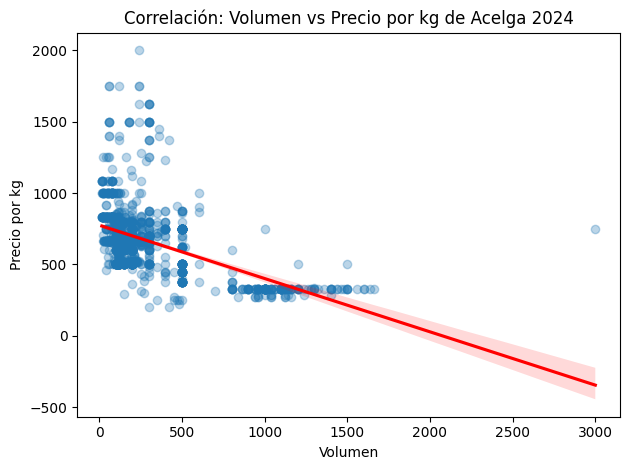

In [ ]:
# Use seaborn puramente por comodidad en comparacion con matplotlib. Ademas, como solo me interesa ver la correlecion de manera visual 
# es innecesario usar las herramientas interactias de plotly

sns.regplot(            # Linea de tendencia precio_kg = β₀ + β₁(pendiente negativa -0.51) × Volumen
    data=df_filtrado3,
    x="Volumen",
    y="precio por kg",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Correlación: Volumen vs Precio por kg de Acelga 2024")
plt.xlabel("Volumen")
plt.ylabel("Precio por kg")
plt.tight_layout()
plt.show()


# Pregunta 3
¿Es posible predecir el precio del producto utilizando un modelo de regresion lineal?

Para responder esta pregunta se construyeron tres modelos de regresión lineal con distintas combinaciones de variables:
- **Modelo 1:** Solo tiempo (día del año)
- **Modelo 2:** Solo volumen comercializado
- **Modelo 3:** Tiempo + volumen (combinado)

Se evaluo cada modelo con dos enfoques de partición: aleatorio (`train_test_split`) y el que dio mejores resultados con temporal(`sort_values`) utilizando los últimos meses como test.

In [ ]:
producto_modelo = "Acelga"

df_modelo = df_kg[df_kg["Producto"] == producto_modelo]  # Siempre usamos el dataset filtrado para el producto deseado
# df_modelo.head()
# df_modelo["Fecha"] = pd.to_datetime(df_modelo["Fecha"])  # Este paso es por si acaso se me ocurre probar con otros datasets
                                                           # Recordar que se transformaron los datos en un rincipio del proyecto
df_modelo["dia_del_año"] = df_modelo["Fecha"].dt.dayofyear #Nueva fila, dt.dayofyear convertimos cada fecha a un numero entre 1-366


# Para el modelo utilizaremos dos variables que creemos explican la variacion de precios. El tiempo analizado por los dias del año
# y el volumen comercializado (oferta del mercado)
# Son los datos que utilizaremos para entrenar el modelo
# precio=β0​+β1​⋅dia_del_año -> precio=β0​+β1​⋅Volumen+β2​⋅dia_del_ano mas ROBUSTO en teoria
# esperamos algo como: el precio baja cuando hay mas volumen, y cambia segun la epoca del año o similares

# Solo tiempo
X1 = df_modelo[["dia_del_año"]]
y1 = df_modelo["precio por kg"]
# Solo volumen
X2 = df_modelo[["Volumen"]]
y2 = df_modelo["precio por kg"]
# Ambos
X3 = df_modelo[["Volumen", "dia_del_año"]]
y3 = df_modelo["precio por kg"]


In [ ]:
from sklearn.model_selection import train_test_split#Es el estandar
                                                    #Mescla los datos aleatoriamente
                                                    #Facil de usar 
                                                    #Aprende patrones de todo el año
from sklearn.linear_model import LinearRegression   #Para entrenar modelos 
from sklearn.metrics import mean_absolute_error, r2_score #Metricas de evaluacion

#mean_absolute_error: Error promedio absoluto 1/n *SUM|yreal-ypredictivo| 
#r2_score: que tan bien el modelo ecplica los datos
#1: excelente
#0: No explica nada
#-1: Peor que adivinar
#Ocultamos parte de los datos al modelo para ver si realmente aprende los ptrones o solo memoriza
#x_train datos para entrenar   80% Entrenamiento
#X_test datos para probar      20% Prueba
#y_train respuestas correctas (train)
#y_test respuestas correctas (test) 

#Modelo 1 (solo tiempo)
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

#Modelo 2 (solo volumen)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

#Modelo 3 (ambos)
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)  
#--------------------------------------------------





In [52]:
#Entrenamiento de los 3 modelos 
modelo1 = LinearRegression()   #Solo tiempo
modelo2 = LinearRegression()   #Solo volumen
modelo3 = LinearRegression()   #Ambos

#Entrenamiento/ aprendizaje 
#Buscan ajustar β para reducir el error
modelo1.fit(X1_train, y1_train)  #precio = β0 + β1 * dia_del_año
modelo2.fit(X2_train, y2_train)  #precio = β0 + β1 * Volumen
modelo3.fit(X3_train, y3_train)  #precio = β0 + β1 * Volumen + β2 * dia_del_año

#Predicciones de los 3 modelos
# Aplican lo aprendido
y1_pred = modelo1.predict(X1_test)
y2_pred = modelo2.predict(X2_test)
y3_pred = modelo3.predict(X3_test)


In [53]:

#Evaluacion
def evaluar_modelo(y_test, y_pred, nombre):    #Creamos una funcion general y evaluamos 
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"--- {nombre} ---")
    print("MAE:", round(mae, 2))
    print("R2:", round(r2, 3))
    print()

evaluar_modelo(y1_test, y1_pred, "Solo tiempo")
evaluar_modelo(y2_test, y2_pred, "Solo volumen")
evaluar_modelo(y3_test, y3_pred, "Tiempo + Volumen")

--- Solo tiempo ---
MAE: 167.04
R2: 0.01

--- Solo volumen ---
MAE: 146.36
R2: 0.147

--- Tiempo + Volumen ---
MAE: 148.46
R2: 0.162



In [ ]:
# Vemos que la media de precios pra 
display(df_modelo["precio por kg"].min())
display(df_modelo["precio por kg"].max())
display(df_modelo["precio por kg"].mean())

np.float64(200.0)

np.float64(2000.0)

np.float64(659.7775684501381)

Resultados: Particion aleatoria
El error absoluto medio (MAE) se mantiene alrededor de $150 en los tres modelos, lo que representa aproximadamente un 23% del precio promedio de la acelga (~$660/kg). Esto indica una capacidad predictiva limitada (Se equivoca un 23% en promedio).

El coeficiente de determinación (R^2) mejora levemente al incorporar una variable mas, pero sigue siendo bajo, lo que indica que el modelo explica solo una fraccion pequeña de la variabilidad del precio por kilogramo.

El tiempo (dia del año) explica poco por si solo, mientras que el volumen presenta una mejor relacion con el precio, consistente con la logica de oferta y demanda. La combinacion de ambas variables mejora marginalmente el desempeño, pero no de forma suficiente para una prediccion confiable.

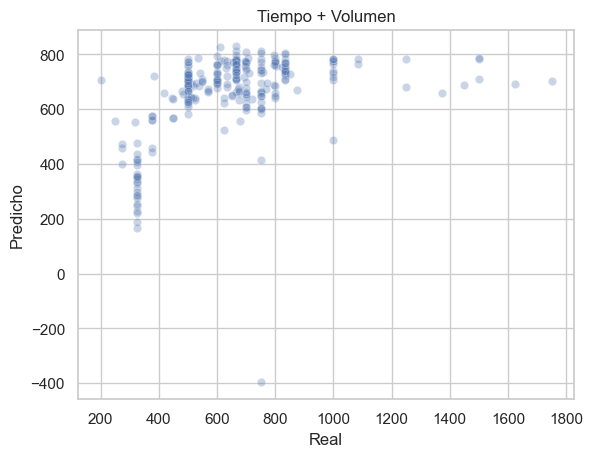

In [ ]:
sns.set_theme(style="whitegrid")

#No interesante de graficar
#Muy dispersos, incluso mas que el modelo tiempo+volumen
#  Modelo 1
#sns.scatterplot(x=y1_test, y=y1_pred, alpha=0.3)
#plt.title("Solo tiempo")
#plt.xlabel("Real")
#plt.ylabel("Predicho")
#plt.show()

#  Modelo 2
#sns.scatterplot(x=y2_test, y=y2_pred, alpha=0.3)
#plt.title("Solo volumen")
#plt.xlabel("Real")
#plt.ylabel("Predicho")
#plt.show()

#  Modelo 3
sns.scatterplot(x=y3_test, y=y3_pred, alpha=0.3)
plt.title("Tiempo + Volumen")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.show()

El error absoluto medio se mantiene alrededor de 150 (entre los tres casos), lo que representa una proporcion relevante respecto al precio del producto, indicando una capacidad predictiva limitada. 150/650 aprox 23% (Se equivoca un 23% en promedio)
El coeficiente de determinación (R^2) aumenta levemente al incorporar la variable de volumen de comercializado, aunque su valor sigue siendo bajo, por lo que el modelo explica solo una pequeña parte de la variabilidad del precio.

Se observa que la variable tiempo no aporta capacidad explicativa importante, al menos no por si sola, mientras que el volumen presenta una relacion mas clara con el precio consistente con la logica de oferta y demanda.
La combinacion de ambas variables mejora marginalmente el desempeño del modelo, aunque sigue siendo insuficiente para una prediccion precisa.

Enfoque alternativo: Division temporal

La particion aleatoria mezcla datos de todo el año, lo que puede inflar artificialmente el desempeño del modelo (poco realista) y apesar de no haber obtenido los resultados deseados es interesante analizar este enfoque para una evaluacion mas realista donde el modelo predice precios futuros a partir de datos del pasado.

 Se utilizara el 80% de los datos iniciales como entrenamiento y el 20% final como test.

In [ ]:
#Probando otro enfoque
#train_test_split mezcla datos
#sort+corte respeta el tpo
# Probablemente de MAS disperso pero es interesante verlo
df_modelo2 = df_modelo.sort_values("Fecha") #ordenar por fechas

#split temporal 
corte = int(len(df_modelo) * 0.8)

train = df_modelo2.iloc[:corte]
test = df_modelo2.iloc[corte:]

# modelo completo
Xtv_train = train[["Volumen", "dia_del_año"]]
ytv_train = train["precio por kg"]

Xtv_test = test[["Volumen", "dia_del_año"]]
ytv_test = test["precio por kg"]

# entrenamiento
modelotv = LinearRegression()
modelotv.fit(Xtv_train, ytv_train)

# predicción
ytv_pred = modelotv.predict(Xtv_test)

# evaluación
mae_tv = mean_absolute_error(ytv_test, ytv_pred)
r2_tv = r2_score(ytv_test, ytv_pred)

#Efectivamente, dio peores resultados
print("\nMODELO TIEMPO + VOLUMEN")
print("MAE:", round(mae_tv, 2))
print("R2:", round(r2_tv, 3))


MODELO TIEMPO + VOLUMEN
MAE: 213.34
R2: -0.19


Text(0, 0.5, 'Precio por kg')

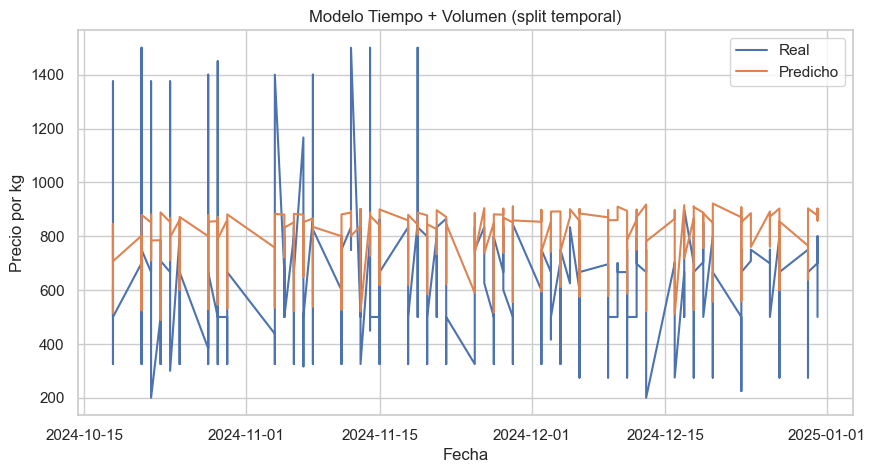

In [62]:
#graficar
plt.figure(figsize=(10,5))

plt.plot(test["Fecha"], ytv_test, label="Real")
plt.plot(test["Fecha"], ytv_pred, label="Predicho")

plt.legend()
plt.title("Modelo Tiempo + Volumen (split temporal)")
plt.xlabel("Fecha")
plt.ylabel("Precio por kg")


Resultados: Particion temporal

El modelo con division temporal presenta un desempeño notablemente peor: el R^2 es negativo, por tanto el modelo falla al generalizar hacia datos futuros y predice peor que simplemente usar el promedio como estimacion.
Esto revela que el modelo aprende patrones distribuidos en el tiempo, pero NO logra capturar la tendencia real cuando se enfrenta a datos que no ha visto.

La regresion lineal con las variables disponibles (tiempo y volumen) **no es suficiente para predecir el precio de la acelga con precision**. Los resultados sugieren que el comportamiento del precio esta influenciado por factores no capturados en este estudio: calidad, origen, region, condiciones climaticas, entre otros.

Un modelo predictivo mas robusto requeriria variables adicionales o enfoques mas complejos (por ejemplo, modelos de series de tiempo o arboles de decision con mas features).
